In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory

from plot_utils import copy_fig_to_clipboard

# --------------------------------------------------
# Paths
# --------------------------------------------------
WORKDIR   = Path().resolve()
REPO_ROOT = WORKDIR.parents[2]
os.chdir(WORKDIR)

sys.path.insert(0, str(WORKDIR))

data_folder   = REPO_ROOT / "LT_UMD_Exp_Data" / "LT_UMD_Exp_Data" / "Pol 1"
data_save_dir = WORKDIR
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Repo root  :", REPO_ROOT)
print("Data folder:", data_folder)
print("Data folder exists:", data_folder.exists())
print("Working dir:", WORKDIR)


Repo root  : D:\Ligentic_NU_1_TapeOut_April2026
Data folder: D:\Ligentic_NU_1_TapeOut_April2026\LT_UMD_Exp_Data\LT_UMD_Exp_Data\Pol 1
Data folder exists: True
Working dir: D:\Ligentic_NU_1_TapeOut_April2026\scripts\directional_coupler\Verification_Kex_J


=== Header ===
  PWR: 1.0
  WAV1: 1540.0
  WAV2: 1560.0
  STP: 1.0
  trigger_step: 0.1
  N: 100.0
  WAV0: 1545.0
  CYC: 5.0
  mode_temp: 0.0
  PWR_Range: 2.257

Thru raw shape : (1766666, 4)
Drop raw shape : (1766666, 4)


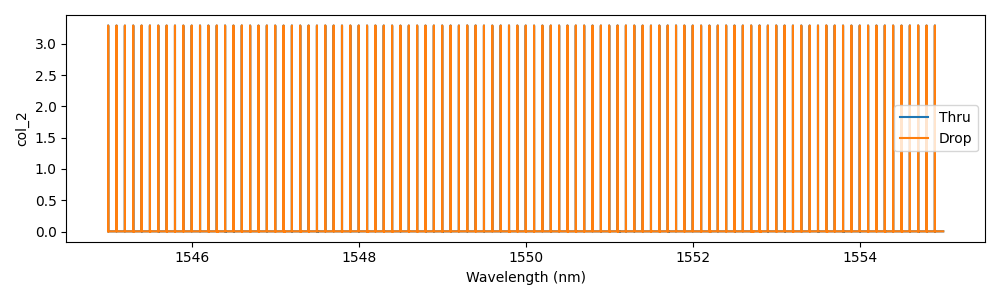

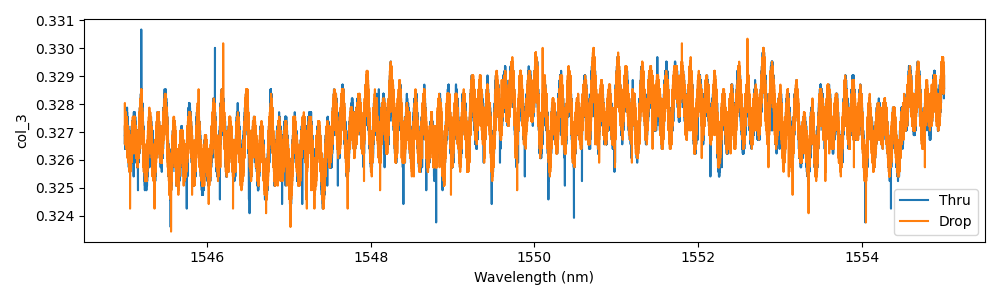

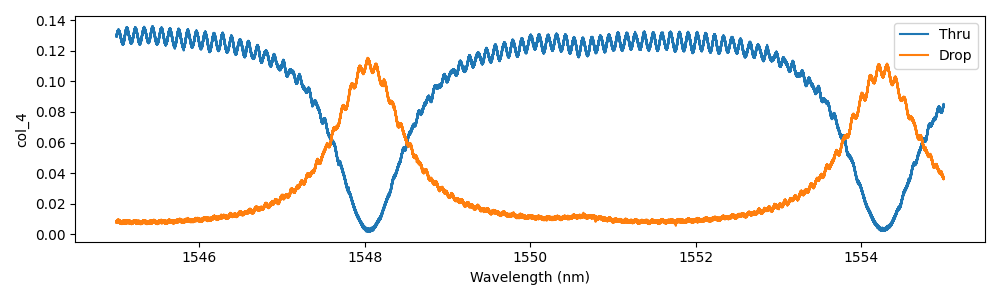

In [ ]:
# --------------------------------------------------
# Device metadata
# --------------------------------------------------
Width  = 1.2   # um
Height = 0.8   # um
Device = "ADF_10"
Gap    = 300   # nm

Data_TH = data_folder / "220511_Chip3_D1_ADF_10_E_Core_1p2_GAP_300_Thru_1p0mW_1540_to_1560_FullSetup_POST5050_0p396.txt"
Data_DR = data_folder / "220511_Chip3_D1_ADF_10_E_Core_1p2_GAP_300_Drop_1p0mW_1540_to_1560_FullSetup_POST5050_0p396.txt"

# --------------------------------------------------
# Load raw data
# --------------------------------------------------
def parse_adf_txt(filepath):
    header_keys = ['PWR', 'WAV1', 'WAV2', 'STP', 'trigger_step', 'N', 'WAV0', 'CYC', 'mode_temp', 'PWR_Range']
    with open(filepath, 'r') as f:
        lines = f.readlines()
    header = {k: float(lines[i+1].strip()) for i, k in enumerate(header_keys)}
    data_lines = lines[11:]
    data = np.array([[float(v) for v in line.split()] for line in data_lines if line.strip()])
    df = pd.DataFrame(data, columns=['wavelength', 'col_2', 'col_3', 'col_4'])
    return header, df

header_TH, df_TH_raw = parse_adf_txt(Data_TH)
header_DR, df_DR_raw = parse_adf_txt(Data_DR)

print("=== Header ===")
for k, v in header_TH.items():
    print(f"  {k}: {v}")
print(f"\nThru raw shape : {df_TH_raw.shape}")
print(f"Drop raw shape : {df_DR_raw.shape}")

# --------------------------------------------------
# Plot raw columns 
# --------------------------------------------------
wav_min, wav_max = 1545, 1555

mask_TH = (df_TH_raw['wavelength'] >= wav_min) & (df_TH_raw['wavelength'] <= wav_max)
mask_DR = (df_DR_raw['wavelength'] >= wav_min) & (df_DR_raw['wavelength'] <= wav_max)

col1_dB = 10 * np.log10(df_DR_raw.loc[mask_DR, 'col_2'] / df_TH_raw.loc[mask_TH, 'col_2'])
col2_dB = 10 * np.log10(df_DR_raw.loc[mask_DR, 'col_3'] / df_TH_raw.loc[mask_TH, 'col_3'])
col3_dB = 10 * np.log10(df_DR_raw.loc[mask_DR, 'col_4'] / df_TH_raw.loc[mask_TH, 'col_4'])

for col in ['c', 'col_3', 'col_4']:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(df_TH_raw.loc[mask_TH, 'wavelength'], df_TH_raw.loc[mask_TH, col], label='Thru')
    ax.plot(df_DR_raw.loc[mask_DR, 'wavelength'], df_DR_raw.loc[mask_DR, col], label='Drop')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(col)
    ax.legend()
    plt.tight_layout()
    plt.show()